# Liver Segmentation using fastai and ResNet

In [ ]:
#%%======================= Install, as needed ================================
#pip install torch==1.6.0+cu101 torchvision==0.7.0+cu101 -f https://download.pytorch.org/whl/torch_stable.html
#pip install torch torchvision -f https://download.pytorch.org/whl/cu126
#pip install --upgrade kornia
#pip install allennlp==1.1.0.rc4
#pip install --upgrade fastai
#pip install --upgrade nibabel
#pip install --upgrade opencv-python
#pip install --upgrade imageio
#pip install --upgrade ipywidgets

In [3]:
#======================= Imports =========================================
import numpy as np 
import pandas as pd 
import os
#os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import matplotlib.pyplot as plt
import glob

import nibabel as nib
import cv2
import imageio
from tqdm.notebook import tqdm
from ipywidgets import *
from PIL import Image

import fastai; fastai.__version__

from fastai.basics import *
from fastai.vision.all import *
from fastai.data.transforms import *

import gc

## ============= Prepare for data imports (collect CT scan image file names)  ==========

In [4]:
#Note: .nii files are the standard file format for Neuroimaging Informatics Technology Initiative (NIfTI) images, 
#commonly used to store 3D or 4D medical imaging data like MRIs, CT scans, and PET scans.

DATASOURCE = "/media/volume/Data/Projects/LITS/data/LiverTumor"

file_list = []
for dirname, _, filenames in os.walk(DATASOURCE + '/masks'):
    for filename in filenames:
#         print(os.path.join(dirname, filename))
        file_list.append((dirname,filename)) 

for dirname, _, filenames in os.walk(DATASOURCE + '/volumes'):
    for filename in filenames:
        file_list.append((dirname,filename)) 

df_files = pd.DataFrame(file_list, columns =['dirname', 'filename']) 
df_files.sort_values(by=['filename'], ascending=True)    


,dirname,filename
121,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-0.nii
104,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-1.nii
29,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-10.nii
128,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-100.nii
80,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-101.nii
...,...,...
139,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt5,volume-50.nii
169,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt1,volume-6.nii
166,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt1,volume-7.nii
165,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt1,volume-8.nii


## == Dictionary: Image file-label ===========

In [5]:
df_files["mask_dirname"] = "" ; df_files["mask_filename"] = ""

for i in range(131):
    ct = f"volume-{i}.nii"
    mask = f"segmentation-{i}.nii"
    
    df_files.loc[df_files['filename'] == ct, 'mask_filename'] = mask
    df_files.loc[df_files['filename'] == ct, 'mask_dirname'] = DATASOURCE + "/masks/segmentations"

# drop segment rows
df_files = df_files[df_files.mask_filename != ''].sort_values(by=['filename']).reset_index(drop=True) 
print(len(df_files))
df_files

51


,dirname,filename,mask_dirname,mask_filename
0,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt1,volume-0.nii,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-0.nii
1,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt1,volume-1.nii,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-1.nii
2,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt1,volume-10.nii,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-10.nii
3,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt2,volume-11.nii,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-11.nii
4,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt2,volume-12.nii,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-12.nii
5,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt2,volume-13.nii,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-13.nii
6,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt2,volume-14.nii,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-14.nii
7,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt2,volume-15.nii,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-15.nii
8,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt2,volume-16.nii,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-16.nii
9,/media/volume/Data/Projects/LITS/data/LiverTumor/volumes/volume_pt2,volume-17.nii,/media/volume/Data/Projects/LITS/data/LiverTumor/masks/segmentations,segmentation-17.nii


# ========== Load CT scan image files ============

In [ ]:
def read_nii(filepath):
    '''
    Reads .nii file and returns pixel array
    '''
    ct_scan = nib.load(filepath)
    array   = ct_scan.get_fdata()
    array   = np.rot90(np.array(array))
    return(array)

# Read sample
sample = 0
sample_ct   = read_nii(df_files.loc[sample,'dirname']+"/"+df_files.loc[sample,'filename'])
sample_mask  = read_nii(df_files.loc[sample,'mask_dirname']+"/"+df_files.loc[sample,'mask_filename'])
sample_ct.shape, sample_mask.shape

print(np.amin(sample_ct), np.amax(sample_ct))
print(np.amin(sample_mask), np.amax(sample_mask))

# =========== Utility plot =============

In [6]:
#use this for plotting from two nipy slices (typically image and mask) 
def plot_sample(array_list, color_map = 'nipy_spectral'):
    '''
    Plots and a slice with all available annotations
    '''
    fig = plt.figure(figsize=(18,15))

    plt.subplot(1,4,1)
    plt.imshow(array_list[0], cmap='bone')
    plt.title('Original Image')
    
    plt.subplot(1,4,2)
    plt.imshow(tensor(array_list[0].astype(np.float32)).windowed(*dicom_windows.liver), cmap='bone');
    plt.title('Windowed Image')
    
    plt.subplot(1,4,3)
    plt.imshow(array_list[1], alpha=0.5, cmap=color_map)
    plt.title('Mask')
    
    plt.subplot(1,4,4)
    plt.imshow(array_list[0], cmap='bone')
    plt.imshow(array_list[1], alpha=0.5, cmap=color_map)
    plt.title('Liver & Mask')


    plt.show()
#use this from plotting nipy mask slice
#and predicted mask slice
#the first parameter must be the liver nipy image
def plot_sample2(array_list, color_map = 'nipy_spectral'):
    '''
    Plots and a slice with all available annotations
    '''
    fig = plt.figure(figsize=(18,15))

    plt.subplot(1,4,1)
    plt.imshow(array_list[1], alpha=0.5, cmap=color_map)
    plt.title('Original Mask')
    
    plt.subplot(1,4,2)
    plt.imshow(array_list[0], cmap='bone')
    plt.imshow(array_list[1], alpha=0.5, cmap=color_map)
    plt.title('Liver & Original Mask')
    
    plt.subplot(1,4,3)
    plt.imshow(array_list[2], alpha=0.5, cmap=color_map)
    plt.title('Predicted Mask')
    
    plt.subplot(1,4,4)
    plt.imshow(array_list[0], cmap='bone')
    plt.imshow(array_list[2], alpha=0.5, cmap=color_map)
    plt.title('Liver & Predicted Mask')


    plt.show()


-3024.0 1410.0
0.0 2.0


# ============ Preprocess the nii file  ========

In [ ]:
# Source https://docs.fast.ai/medical.imaging

dicom_windows = types.SimpleNamespace(
    brain=(80,40),
    subdural=(254,100),
    stroke=(8,32),
    brain_bone=(2800,600),
    brain_soft=(375,40),
    lungs=(1500,-600),
    mediastinum=(350,50),
    abdomen_soft=(400,50),
    liver=(150,30),
    spine_soft=(250,50),
    spine_bone=(1800,400),
    custom = (200,60)
)

@patch
def windowed(self:Tensor, w, l):
    px = self.clone()
    px_min = l - w//2
    px_max = l + w//2
    px[px<px_min] = px_min
    px[px>px_max] = px_max
    return (px-px_min) / (px_max-px_min)

plt.imshow(tensor(sample_ct[...,50].astype(np.float32)).windowed(*dicom_windows.liver), cmap=plt.cm.bone);

In [ ]:
# ============= Plot a sample ==========

In [ ]:
sample=50
sample_slice = tensor(sample_ct[...,sample].astype(np.float32))
sample_mask_slice = tensor(sample_mask[...,sample].astype(np.float32))

plot_sample([sample_ct[...,sample], sample_mask[...,sample]])


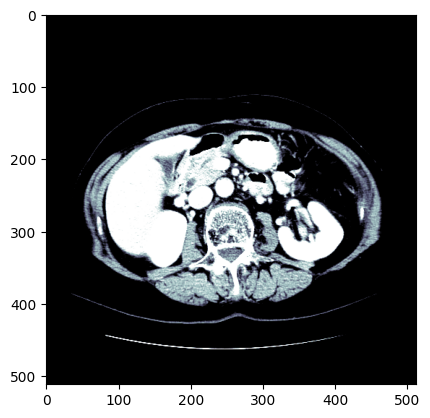

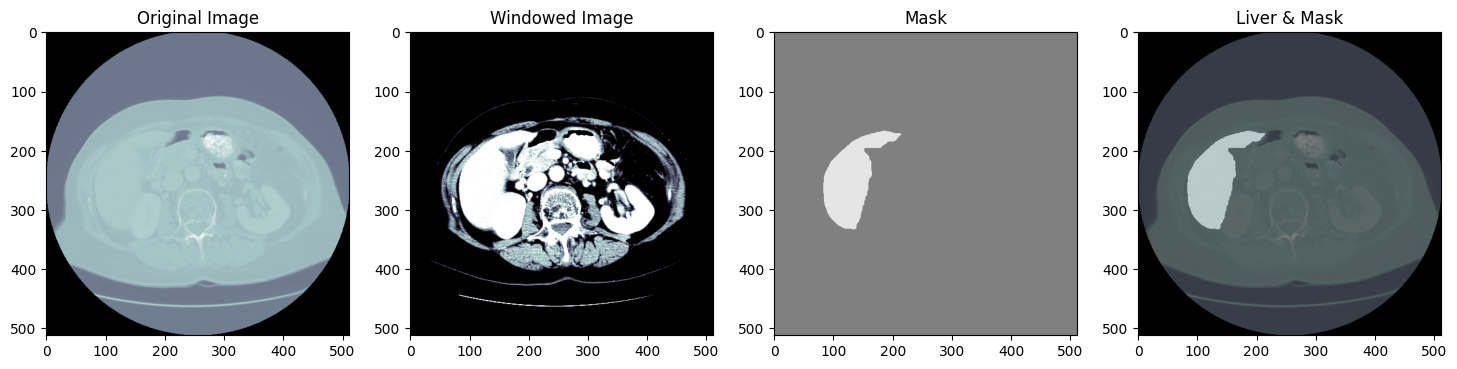

[[     0 252049]
 [     1  10095]]


In [7]:
#%%===================== check sample's mask ============================================
mask = Image.fromarray(sample_mask[...,sample].astype('uint8'), mode="L")
unique, counts = np.unique(mask, return_counts=True)
print( np.array((unique, counts)).T)
